# 03 · Causation — effect, uplift, and the divergence

> Synthetic data; identification assumptions are demonstrative and probed with refutation tests.

Thin wrapper over `src/causal` and `src/policy`. Regenerate with `make causal && make policy` (the causal forest takes a minute); here we read the committed results.

In [1]:
import os, sys
from pathlib import Path

# Make the repo root the working dir and importable, whether this notebook is
# launched from notebooks/ or from the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /Users/jimmy/Documents/hr-attrition-analytics


## Identification + refutation (DoWhy)

Backdoor ATE of `OverTime` on attrition, with three refuters. Read: placebo new-effect ≈ 0 = good; random-common-cause / subset ≈ estimated = robust.

In [2]:
display(pd.read_csv('figures/refutation.csv').round(4))

,refuter,estimated_effect,new_effect,p_value
0,placebo_treatment,0.1866,-0.0033,0.4122
1,random_common_cause,0.1866,0.1866,0.1587
2,data_subset,0.1866,0.1924,0.3533


## Heterogeneous uplift (EconML CausalForestDML)

The same intervention helps some employees far more than others — that spread is what a sensible policy targets.

In [3]:
cate = pd.read_csv('figures/cate_test.csv')
print('columns:', list(cate.columns))
display(cate.describe().round(4))

columns: ['causal_forest', 't_learner']


,causal_forest,t_learner
count,368.0000,368.0000
mean,0.1853,0.1914
std,0.0884,0.1554
min,0.0333,-0.0599
25%,0.1176,0.0698
50%,0.1649,0.1493
75%,0.2328,0.2856
max,0.3997,0.6049


## The divergence result — the figure the project exists for

Risk ranking ≠ uplift ranking.

,n_test,k_top_decile,spearman_rho,top_decile_overlap,risk_targeting_efficiency,risk_top_share_not_on_overtime
0,368,37,0.53477,0.27027,0.741823,0.378378


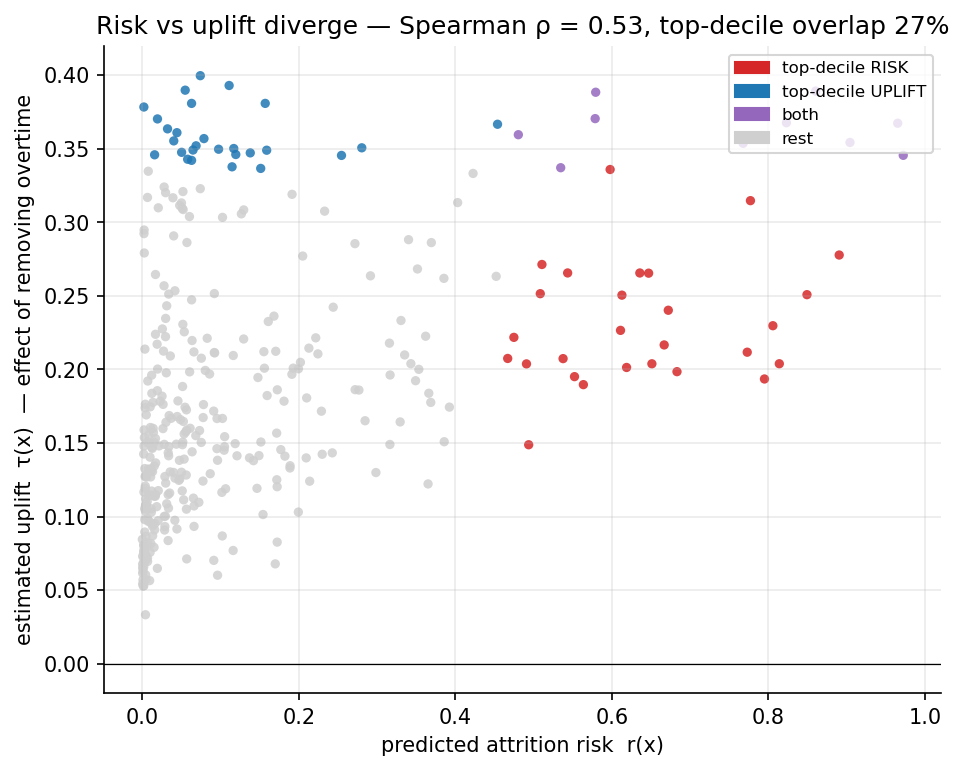

In [4]:
display(pd.read_csv('figures/divergence_stats.csv'))
Image('figures/divergence.png')

## Causally-grounded policy simulation

Uplift-targeting beats risk-targeting at every budget; the full causal redo is 16.0%→11.1%, not v1's naive 16.0%→7.8%.

,budget_frac,k,reduction_risk,reduction_uplift,post_risk,post_uplift,post_random,efficiency_risk_vs_uplift
0,0.05,18,0.0090,0.0168,0.1513,0.1436,0.1579,0.5398
1,0.10,37,0.0166,0.0287,0.1437,0.1317,0.1554,0.5793
2,0.20,74,0.0294,0.0445,0.1309,0.1158,0.1504,0.6608


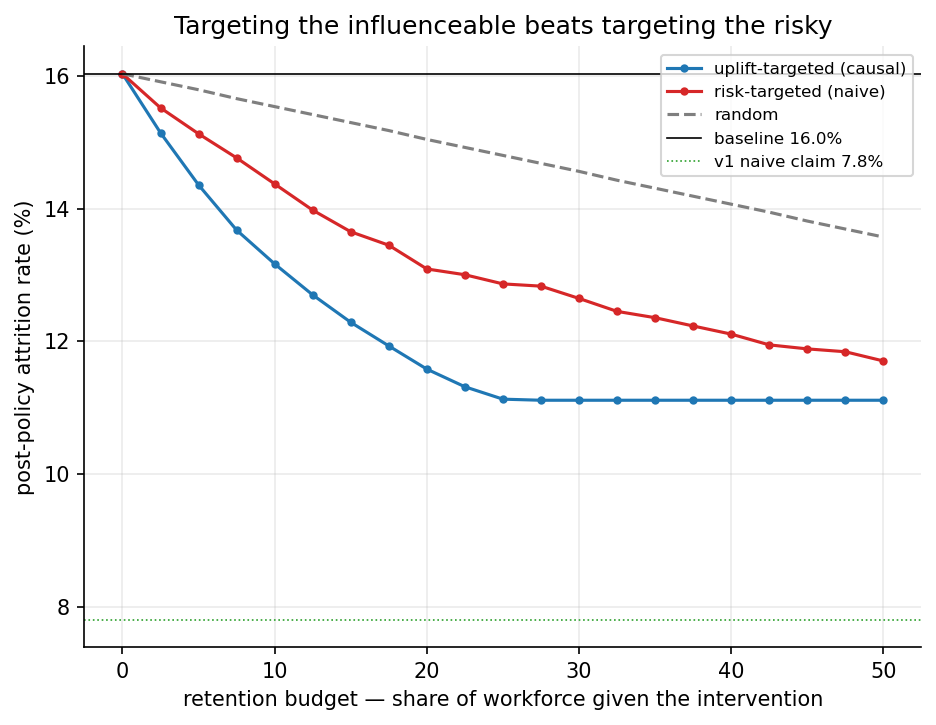

In [5]:
display(pd.read_csv('figures/policy_simulation.csv').round(4))
Image('figures/policy_simulation.png')

**Takeaway.** Targeting the most *at-risk* is not targeting the most *influenceable*; acting on risk wastes a third or more of achievable retention. Next: `04_ethics.ipynb`.